In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
df = pd.read_csv('Lab 21 House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [4]:
# chcek for duplicate values and drop it
dup_values = df.duplicated().sum()
dup_values

np.int64(0)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.simplefilter(action='ignore')

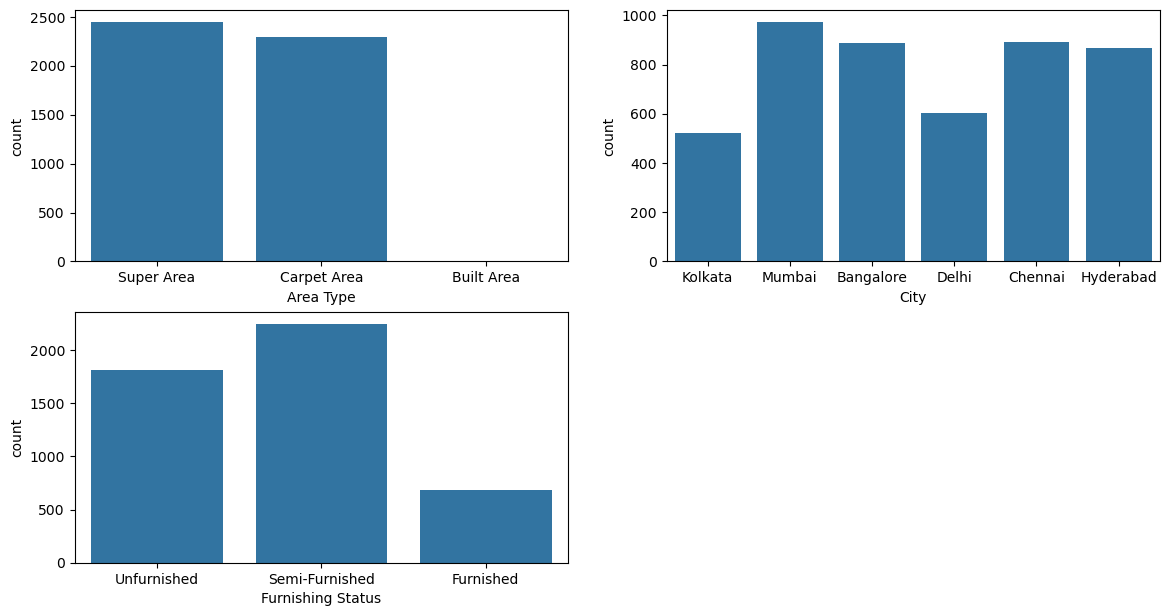

In [6]:
#visualizing the counts of values of objects cols by plotting

plt.figure(figsize=(14,15))
for i,col in enumerate(["Area Type","City","Furnishing Status"]):
    plt.subplot(4,2,i+1)
    sns.countplot(data=df,x=col)

Text(0.5, 1.0, 'Relation betn REnt and BHK by City')

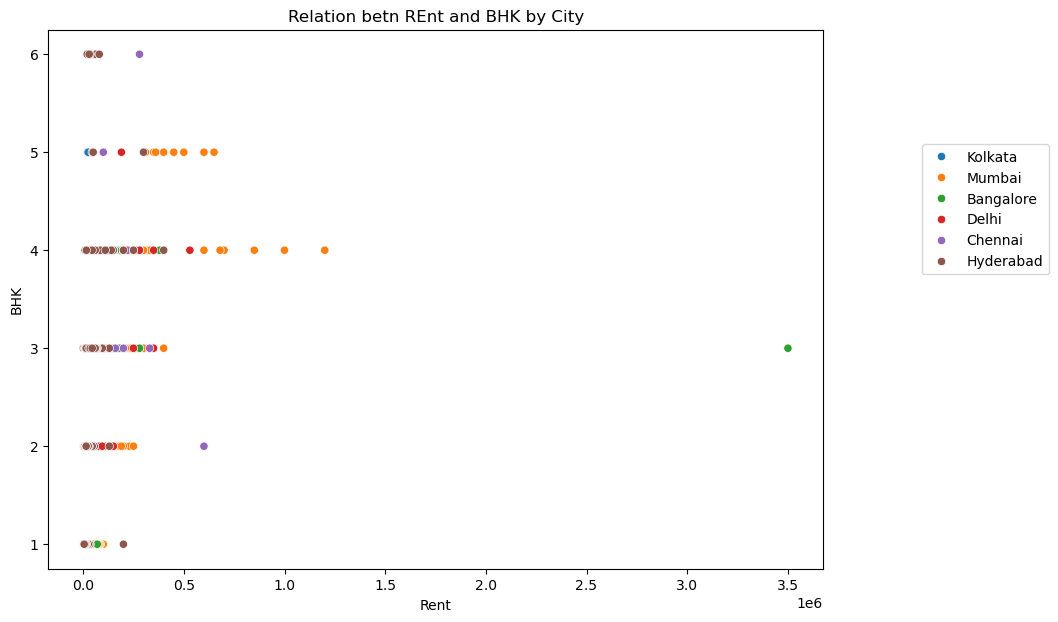

In [7]:
# analyzing relation of rent with bhk

plt.figure(figsize=(10,7))
sns.scatterplot(x='Rent',y='BHK', data = df, hue = "City")
# hue is used for colors by categories

plt.legend(bbox_to_anchor=(1.3,0.8))
plt.title("Relation betn REnt and BHK by City")


<Axes: xlabel='Rent', ylabel='Size'>

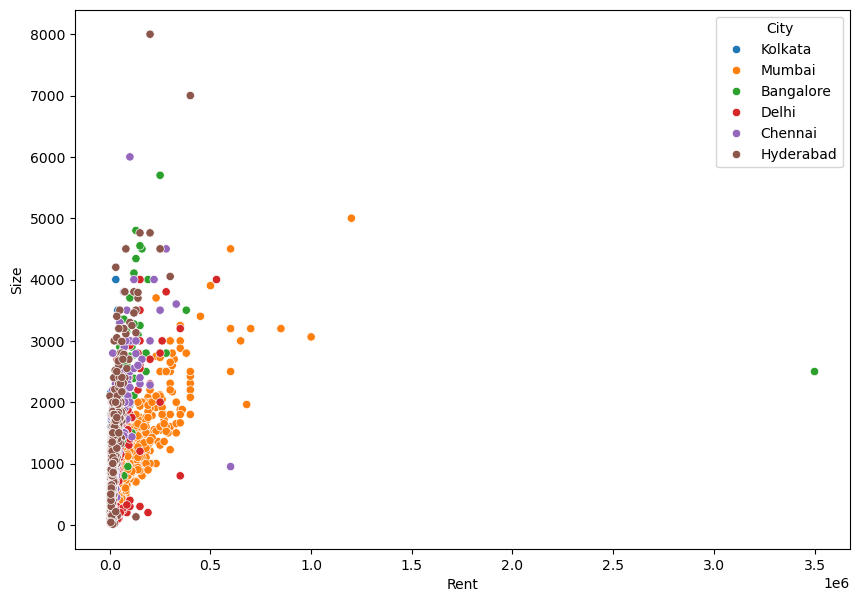

In [8]:
# relation betn rent and size
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x = 'Rent',y='Size', hue='City')


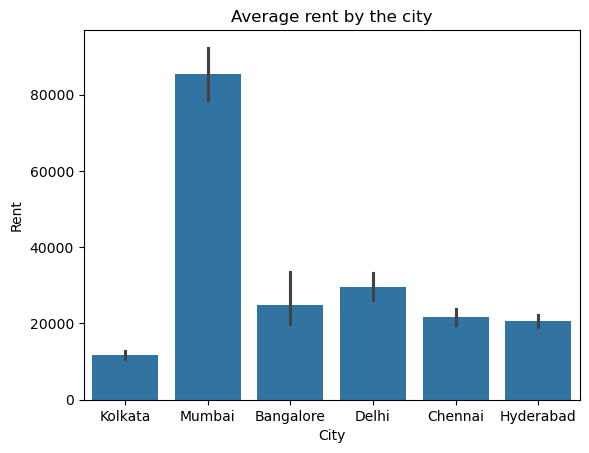

In [9]:
sns.barplot(data = df,x = 'City',y='Rent')
plt.title('Average rent by the city')
plt.show()

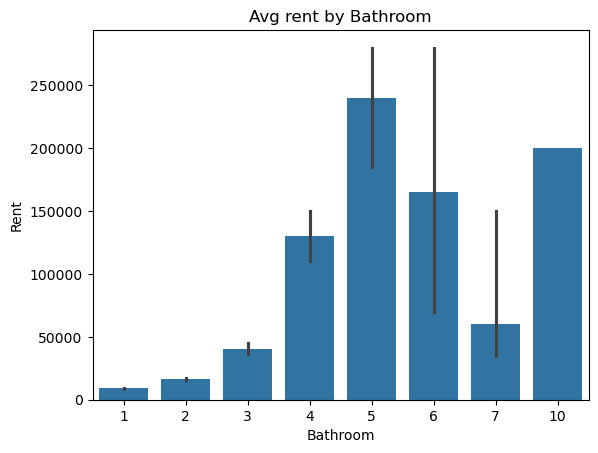

In [10]:
sns.barplot(data = df, x='Bathroom',y='Rent', estimator = np.median)
plt.title('Avg rent by Bathroom')
plt.show()

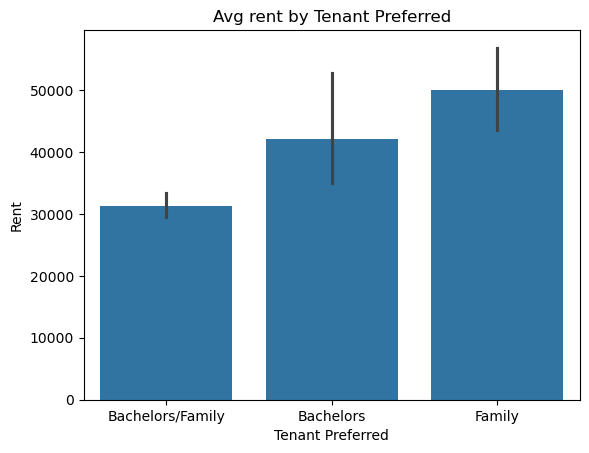

In [11]:
sns.barplot(data = df, x='Tenant Preferred',y='Rent')
plt.title('Avg rent by Tenant Preferred')  # tenant means kiraydar
plt.show()

In [ ]:
!pip install category_encoders
!pip install xgboost
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.svm import SVR
import sklearn.metrics as metrics
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

### Feature Encoding

>> to convert categorical features into numeric feature

#### Techniques for encoding
>> 1. by replacing values manually  # use when no. of category cols are less

>> 2. by labelencoding

>> 3. by one hot encoding # creates new cols of each value and marks that value and marks that value as 1 and rest as 0
                           in that particular feature , increases the dimension of data

>> 4. category encoder  # encode the categories by numbers



#### Feature scaling

>> to convert all numeric cols in same range

1. MinMaxScaler >> scale between 0 to 1
2. Standardscaler >> scale all data betn -3 to 3


In [ ]:
# creating function for evaluation by using error and score 
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance = metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    # mean_squared_log_error = metrics.squared_log_error(y_true, y_pred)
    median_absolute_error = metrics.median_absolute_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)


    print('explained_variance:' , round(explained_variance, 4))
    # print('mean_squared_log_error:', round(mean_squared_log_error,4))
    print('r2:' ,round(r2,4))
    print('MAE:', round(mean_absolute_error,4))
    print('RMSE:', round(np.sqrt(mse),4))
    print('Median Absolute Error:',round(median_absolute_error,4))

In [ ]:
# separate category cols
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

In [ ]:
for col in categorical_cols:
    print(f"{col}:{df[col].nunique()}")

In [ ]:
# dividing input and output feature
x = df.drop(columns = "Rent")
y = df["Rent"]

In [ ]:
!pip install category_encoders
# encoding category features 
encoder = ce.LeaveOneOutEncoder(return_df = True)
x = encoder.fit_transform(x,y)

In [ ]:
# feature scaling 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [ ]:
# converting the output of above in 

x_df = pd.DataFrame(x)
x_df

In [ ]:
# dividing data into training and testing 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 40)

In [ ]:
x_train.shape, x_test.shape

## Training models and evaluating each model

In [ ]:
model_rfr = RandomForestRegressor(n_estimator = 7)
model_dt = Decision_Tree_Regressor()
model_lr = LinearRegression()
# model_xgb = xgb.XGBRegressor(objective = 'reg:squarederror')
models = [model_rfr, model_dt, model_lr, model_xgb]


In [ ]:
for model in models:
    print(f"fitting model: {model}")
    model.fit(x_train, y_train)

In [ ]:
for model in models:
    print(f"score of {model} for training data: {model.score(x_train, y_train)}")